In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../outputs/customer_segments.csv")

print(df.shape)

df.head()

(16737, 35)


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,total_flights,total_distance,total_points_accumulated,total_points_redeemed,total_redeemed_dollars,active_months,first_activity,last_activity,recency_months,avg_flights_per_month,points_redemption_ratio,distance_per_flight,official_churn,behavioral_churn,churn,salary_imputed,tenure_months,cluster,customer_segment
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,37,54525,54525.0,1418,256,24,2017-01-01,2018-12-01,0.0,1.541667,0.026006,1473.648649,0,0,0,83236.0,34,3,Loyal Customers
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,58,77487,77487.0,1971,356,24,2017-01-01,2018-12-01,0.0,2.416667,0.025437,1335.982759,0,0,0,73455.0,33,3,Loyal Customers
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,18,24803,24803.0,374,67,24,2017-01-01,2018-12-01,0.0,0.750000,0.015079,1377.944444,1,0,1,73455.0,53,1,At-Risk Customers
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,35,48432,48432.0,1291,233,24,2017-01-01,2018-12-01,0.0,1.458333,0.026656,1383.771429,0,0,0,73455.0,70,3,Loyal Customers
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,37,55515,55515.0,0,0,24,2017-01-01,2018-12-01,0.0,1.541667,0.000000,1500.405405,0,0,0,103495.0,50,3,Loyal Customers


In [4]:
target = "churn"

print(df[target].value_counts())

print(
    round(
        df[target].value_counts(normalize=True) * 100,
        2
    )
)

churn
0    14670
1     2067
Name: count, dtype: int64
churn
0    87.65
1    12.35
Name: proportion, dtype: float64


In [5]:
features = [

    "salary_imputed",
    "clv",

    "total_flights",
    "total_distance",

    "total_points_accumulated",
    "total_points_redeemed",

    "active_months",

    "avg_flights_per_month",

    "points_redemption_ratio",

    "distance_per_flight",

    "tenure_months"

]

In [6]:
X = df[features]

y = df[target]

print(X.shape)
print(y.shape)

(16737, 11)
(16737,)


In [9]:
X.isnull().sum().sort_values(ascending=False)

distance_per_flight         1570
clv                            0
salary_imputed                 0
total_flights                  0
total_distance                 0
total_points_redeemed          0
total_points_accumulated       0
active_months                  0
avg_flights_per_month          0
points_redemption_ratio        0
tenure_months                  0
dtype: int64

In [11]:
X["distance_per_flight"] = X["distance_per_flight"].fillna(0)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(13389, 11)
(3348, 11)


In [13]:
log_model = LogisticRegression(
    max_iter=500
)

log_model.fit(
    X_train,
    y_train
)

c:\Users\MANIDEEP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [14]:
log_preds = log_model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, log_preds)
)

print(
    "\nPrecision:",
    precision_score(y_test, log_preds)
)

print(
    "\nRecall:",
    recall_score(y_test, log_preds)
)

print(
    "\nF1:",
    f1_score(y_test, log_preds)
)

Accuracy: 0.9229390681003584

Precision: 0.7902621722846442

Recall: 0.5108958837772397

F1: 0.6205882352941177


In [15]:
rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [16]:
rf_preds = rf_model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, rf_preds)
)

print(
    "\nPrecision:",
    precision_score(y_test, rf_preds)
)

print(
    "\nRecall:",
    recall_score(y_test, rf_preds)
)

print(
    "\nF1:",
    f1_score(y_test, rf_preds)
)

Accuracy: 0.9566905615292712

Precision: 0.935064935064935

Recall: 0.6973365617433414

F1: 0.7988904299583911


In [17]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds)
    ],

    "Precision": [
        precision_score(y_test, log_preds),
        precision_score(y_test, rf_preds)
    ],

    "Recall": [
        recall_score(y_test, log_preds),
        recall_score(y_test, rf_preds)
    ],

    "F1 Score": [
        f1_score(y_test, log_preds),
        f1_score(y_test, rf_preds)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.922939,0.790262,0.510896,0.620588
1,Random Forest,0.956691,0.935065,0.697337,0.798890


In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,tenure_months,0.366273
2,total_flights,0.105614
7,avg_flights_per_month,0.097378
4,total_points_accumulated,0.096249
3,total_distance,0.094066
9,distance_per_flight,0.071509
1,clv,0.052303
0,salary_imputed,0.044224
8,points_redemption_ratio,0.035237
5,total_points_redeemed,0.031481


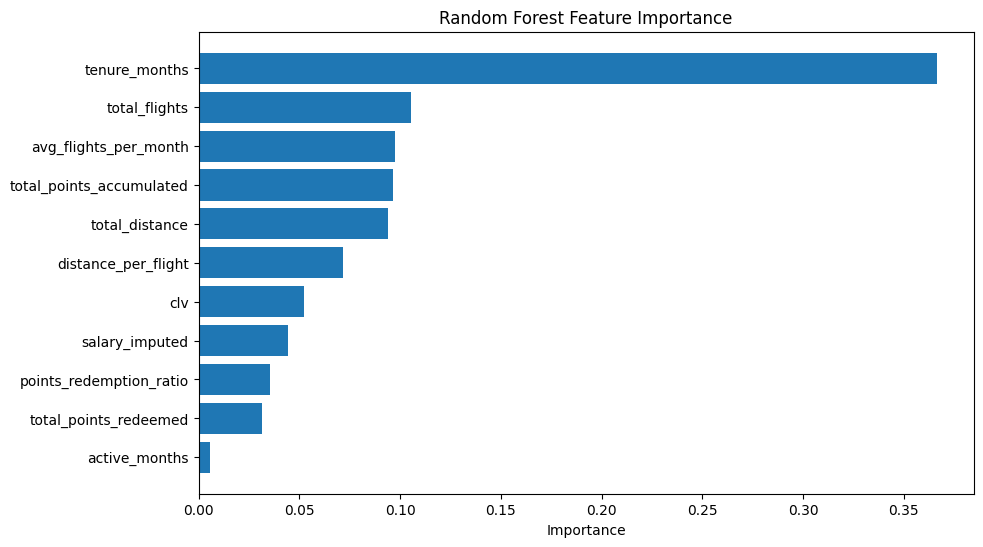

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

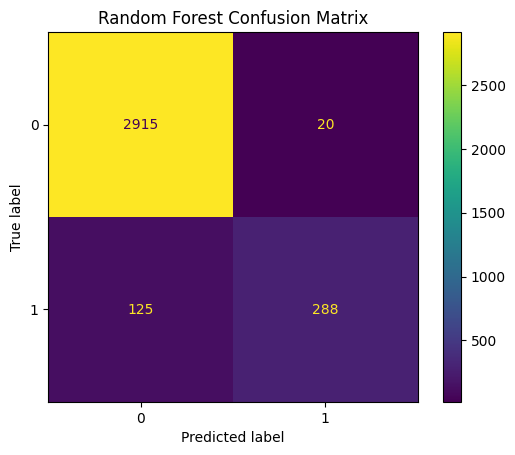

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [21]:
test_results = X_test.copy()

test_results["actual_churn"] = y_test

test_results["predicted_churn"] = rf_preds

test_results.to_csv(
    "../outputs/churn_predictions.csv",
    index=False
)

print("Predictions saved successfully")

Predictions saved successfully


# Final Conclusion

This project analyzed airline loyalty customer behavior and developed a churn prediction framework.

Key achievements:

- Built a customer-level analytical dataset from raw airline data.
- Segmented customers into five business-relevant groups using K-Means clustering.
- Developed churn prediction models using Logistic Regression and Random Forest.
- Random Forest achieved the best performance:
  - Accuracy: 95.67%
  - Precision: 93.51%
  - Recall: 69.73%
  - F1 Score: 79.89%
- Tenure, flight activity, and loyalty engagement were identified as the strongest predictors of churn.

The results can support targeted retention campaigns, loyalty program optimization, and customer value management.